## IIP314W Optimización aplicada a negocios

Soluciones análiticas sin restricción y ejercicios.

### Optimización sin restricciones

La clase anterior, recordamos que en cálculo buscamos la solución análitica derivando la función objetivo y vimos el metodo iterativo **Gradiente Descendente**, esta clase nos centraremos en la identificación de todos los **puntos críticos**, estos también se denominan **estacionarios**. Además repasaremos la caracterización de estos puntos con la segunda derivada, que usted ya conoce. Formalmente:

- Condición de optimalidad de primer orden, para que un punto sea un óptimo local (máximo o mínimo) de una función, la derivada (gradiente) de la función en el punto óptimo es cero.

- Condiciones de optimalidad de segundo orden, un punto estacionario es un mínimo, un máximo o un punto de silla, basándose en la segunda derivada de la función, o su hessiano en multivariable.

#### Ejercicio 1

$$ f(x,y) = (x^2 + 4y^2) e^{(1-x^2-y^2)} $$

1. Verifique que los puntos $x_1 = (0,0), x_2 = (0,1), x_3 = (0,-1), x_4 = (1,0), x_5 = (-1,0)$ son puntos críticos (estacionarios) de f.
2. Indique si corresponde a máximos y mínimos. Justifique.

Veamos si concuerda con el gráfico.

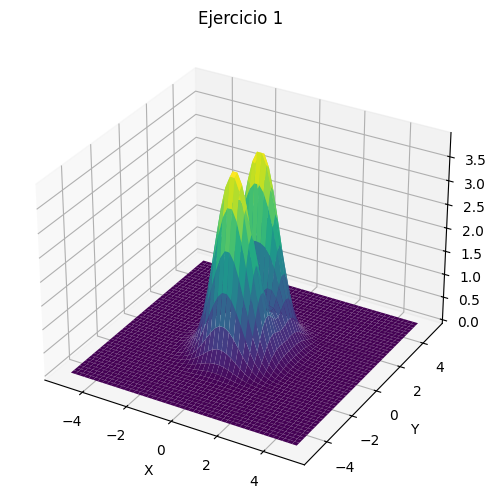

In [36]:
import numpy as np
import matplotlib.pyplot as plt

f = lambda x, y: (x**2+4*y**2)*np.exp(1-x**2-y**2)

x = np.linspace(-5, 5, 50)  # Range of x values
y = np.linspace(-5, 5, 50)  # Range of y values
X, Y = np.meshgrid(x, y)
Z = f(X,Y)

# Crear la figura y el eje 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Graficar la superficie
ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Ejercicio 1')

plt.show()

Veamos si podemos encontrar computacionalmente los puntos criticos.

In [4]:
from scipy.optimize import minimize
import numpy as np

def funcion_objetivo(x):
    return -(x[0]**2+4*x[1]**2)*np.exp(1-x[0]**2-x[1]**2)

solucion_inicial = np.array([0, 0])

# Minimize the function using the Nelder-Mead method
result = minimize(funcion_objetivo, solucion_inicial , method='Nelder-Mead')

# Print the result
print(result)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -3.9999999989677026
             x: [ 1.807e-05  1.000e+00]
           nit: 61
          nfev: 114
 final_simplex: (array([[ 1.807e-05,  1.000e+00],
                       [-5.192e-05,  1.000e+00],
                       [-2.293e-05,  1.000e+00]]), array([-4.000e+00, -4.000e+00, -4.000e+00]))


Revisar: https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html#scipy.optimize.minimize

¿Como obtenemos las demás soluciones?, discutir.

#### Función convexa

Revisar: http://www.ugr.es/~camilo/calculo-ii-grado-en-matemat/apuntes/tema-10.pdf

Importante:

- Regla convexidad, f es convexa si:

$$ f((1-t)a + tb) \le (1-t)f(a) + t f(b)$$ 

Si $f$ es derivable en un intervalo, se puede decir que:
- $f$ es convexa
- $f'$ es creciente
- Para cualquier a en el intervalo, $f(x) \ge f(a) + f'(a) (x-a)$

Estas tres declaraciones son equivalentes.

#### Ejercicio 2.

En Economía, se utiliza frecuentemente la función de producción Cobb-Douglas, la cual para dos insumos tiene la forma:

$$ F(x,y) = K x^\alpha y^\beta$$

donde x, y son las cantidades utilizadas de cada insumo. K es la constante de transformación y $\alpha, \beta \in [0,1]$ se conocen como constantes de elasticidad.

a) Demuestre $F(x,y)$ es estrictamente convexa, $\forall x,y \ge 0$, si $K \lt 0$ y se cumple que $\alpha+\beta \lt 1$.

b) Resuelva el problema de optimización sin restricciones:

$$ mín \left( -12x^{\frac{1}{4}} y^{\frac{1}{2}} + 3 x + 2 y \right) \quad (x,y) \in \mathbb{R}^2$$


- Revisar https://en.wikipedia.org/wiki/Cobb%E2%80%93Douglas_production_function

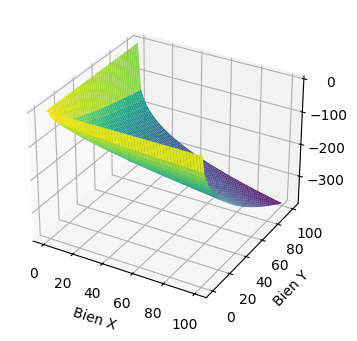

In [38]:
x = y = np.linspace(0, 100, 50) 
X, Y=np.meshgrid(x,y)

def cobb_douglas(x,y):
    alfa=1/4
    beta=1/2
    return(-12*x**(alfa)*y**(beta))

# Crear la figura y el eje 3D
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111, projection='3d')

# Graficar la superficie
ax.plot_surface(X, Y, cobb_douglas(X,Y), cmap='viridis', edgecolor='none')
ax.set_ylabel("Bien Y")
ax.set_xlabel("Bien X")
plt.show()

### Más ejercicios para certamen 1

#### Ejercicio 3.

$$ f(x_1,x_2,x_3) = x_3^3 + x_1^2 + x_2^2 + x_1 x_2 - 5 x_1 - 4 x_2 - 3 x_3 + 1$$

Determine todos los puntos de mínimo local de $f$ o demuestre que no existen. En caso de que $f$ tenga puntos de mínimo local indique si son también mínimos globales.

#### Ejercicio 4.

$$ f(x_1, x_2) = x_1^3 + x_2^3 - 3 x_1 - 12 x_2 + 10 $$

Encuentre, todos los puntos estacionarios de $f(x_1, x_2)$ y para cada uno indique si corresponde a un máximo, mínimo o punto silla.

#### Ejercicio 5.

Considere la función $f: \mathbb{R}^N \rightarrow \mathbb{R}$:

$$ f(\vec{x}) = \sum_{i=0}^N a_i e^{(b_i x_i - c_i)^2} $$

Encuentre la condición de optimalidad de primer orden para $f$ e indique para qué valores de los parámetros $a_i, b_i, c_i$ la condición de primer orden encontrada es suficiente para garantizar que $f$ tiene un punto mínimo. Justifique.

#### Ejercicio 6.

Considere la función $f(x,y) = 8(x-1)^4 - 4(x-1)^2 + 3 y^3 - 4 y^2$. Encuentre todos los puntos estacionarios de f y caracterícelos.